In [1]:
pip install wordcloud textblob nltk

   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 624.3/624.3 kB 11.7 MB/s  0:00:00

   ---------------------------------------- 0/2 [wordcloud]
   ---------------------------------------- 0/2 [wordcloud]
   -------------------- ------------------- 1/2 [textblob]
   -------------------- ------------------- 1/2 [textblob]
   -------------------- ------------------- 1/2 [textblob]
   ---------------------------------------- 2/2 [textblob]

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from textblob import TextBlob
from wordcloud import WordCloud
import os

# Create images folder
os.makedirs('images', exist_ok=True)
sns.set(style="whitegrid")

In [3]:
# Load the dataset
df = pd.read_csv('dataset/twitter_data.csv')

# Keep only relevant columns
df = df[['text', 'airline_sentiment']]

# Inspect the raw text
print(df.head())
print(df['airline_sentiment'].value_counts())

                                                text airline_sentiment
0                @VirginAmerica What @dhepburn said.           neutral
1  @VirginAmerica plus you've added commercials t...          positive
2  @VirginAmerica I didn't today... Must mean I n...           neutral
3  @VirginAmerica it's really aggressive to blast...          negative
4  @VirginAmerica and it's a really big bad thing...          negative
airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64


In [4]:
# Function to clean tweets
def clean_text(text):
    text = str(text).lower() # Lowercase
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # Remove mentions (@User)
    text = re.sub(r'#', '', text) # Remove hashtags
    text = re.sub(r'https?:\/\/\S+', '', text) # Remove links
    text = re.sub(r'[^\w\s]', '', text) # Remove special characters
    return text

# Apply cleaning
df['cleaned_text'] = df['text'].apply(clean_text)

print("Original:", df['text'][0])
print("Cleaned:", df['cleaned_text'][0])

Original: @VirginAmerica What @dhepburn said.
Cleaned:  what  said


In [5]:
# Function to get polarity
def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

# Apply to dataset
df['polarity'] = df['cleaned_text'].apply(get_sentiment)

# Categorize polarity into sentiment
def categorize_score(score):
    if score < 0: return 'negative'
    elif score == 0: return 'neutral'
    else: return 'positive'

df['predicted_sentiment'] = df['polarity'].apply(categorize_score)

print(df[['cleaned_text', 'polarity', 'predicted_sentiment']].head())

                                        cleaned_text  polarity  \
0                                         what  said   0.00000   
1   plus youve added commercials to the experienc...   0.00000   
2   i didnt today must mean i need to take anothe...  -0.31250   
3   its really aggressive to blast obnoxious ente...   0.00625   
4            and its a really big bad thing about it  -0.35000   

  predicted_sentiment  
0             neutral  
1             neutral  
2            negative  
3            positive  
4            negative  


C:\Users\Abin\AppData\Local\Temp\ipykernel_2736\2215685052.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='predicted_sentiment', data=df, palette='coolwarm')


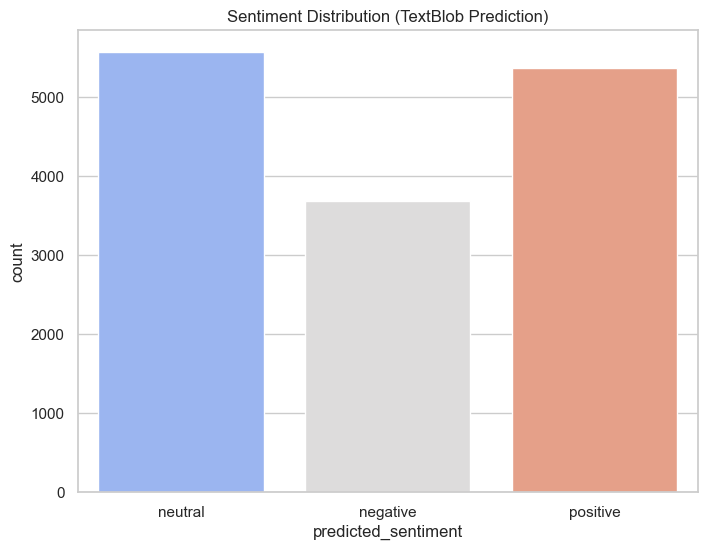

In [6]:
plt.figure(figsize=(8, 6))
sns.countplot(x='predicted_sentiment', data=df, palette='coolwarm')
plt.title('Sentiment Distribution (TextBlob Prediction)')
plt.savefig('images/sentiment_distribution.png')
plt.show()

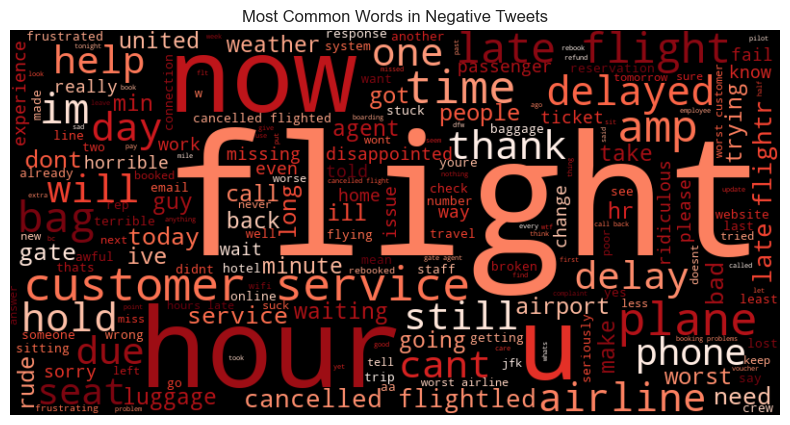

In [7]:
# Separate negative tweets
negative_text = ' '.join(df[df['predicted_sentiment'] == 'negative']['cleaned_text'])

# Generate WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(negative_text)

# Plot
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Negative Tweets')
plt.savefig('images/negative_wordcloud.png')
plt.show()

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

# Convert text to numbers (Vectorization)
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')
X = vectorizer.fit_transform(df['cleaned_text'])
y = df['airline_sentiment'] # Use the ACTUAL labels from the dataset, not our TextBlob guess

# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
# Train Naive Bayes Classifier
model = MultinomialNB()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7469262295081968
              precision    recall  f1-score   support

    negative       0.74      0.98      0.84      1889
     neutral       0.73      0.26      0.38       580
    positive       0.87      0.41      0.56       459

    accuracy                           0.75      2928
   macro avg       0.78      0.55      0.59      2928
weighted avg       0.76      0.75      0.71      2928



In [10]:
def predict_tweet(text):
    clean = clean_text(text)
    vec = vectorizer.transform([clean])
    prediction = model.predict(vec)
    return prediction[0]

# Test it
print("Test 1:", predict_tweet("The flight was amazing and on time!"))
print("Test 2:", predict_tweet("I lost my luggage and the service was terrible."))

Test 1: negative
Test 2: negative


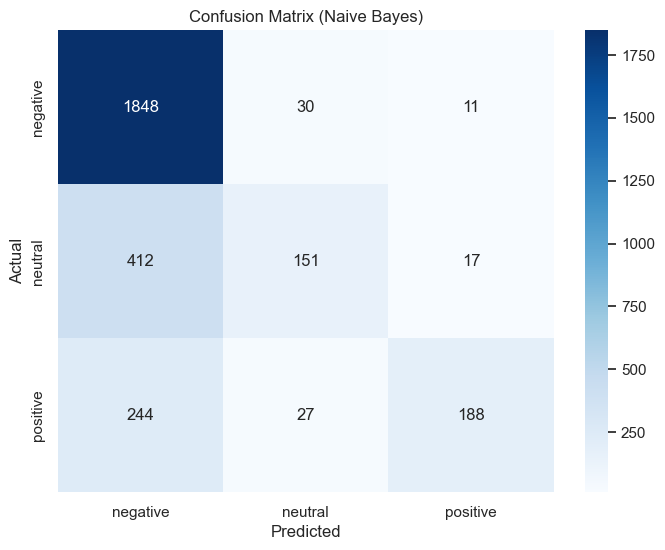

In [13]:
from sklearn.metrics import confusion_matrix

# Generate the matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Confusion Matrix (Naive Bayes)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('images/confusion_matrix_nlp.png')
plt.show()

In [14]:
# Load the dataset
df = pd.read_csv('dataset/twitter_data.csv')

# Keep relevant columns (UPDATED line)
df = df[['text', 'airline_sentiment', 'airline', 'negativereason']]

# Inspect the raw text
print(df.head())

                                                text airline_sentiment  \
0                @VirginAmerica What @dhepburn said.           neutral   
1  @VirginAmerica plus you've added commercials t...          positive   
2  @VirginAmerica I didn't today... Must mean I n...           neutral   
3  @VirginAmerica it's really aggressive to blast...          negative   
4  @VirginAmerica and it's a really big bad thing...          negative   

          airline negativereason  
0  Virgin America            NaN  
1  Virgin America            NaN  
2  Virgin America            NaN  
3  Virgin America     Bad Flight  
4  Virgin America     Can't Tell  


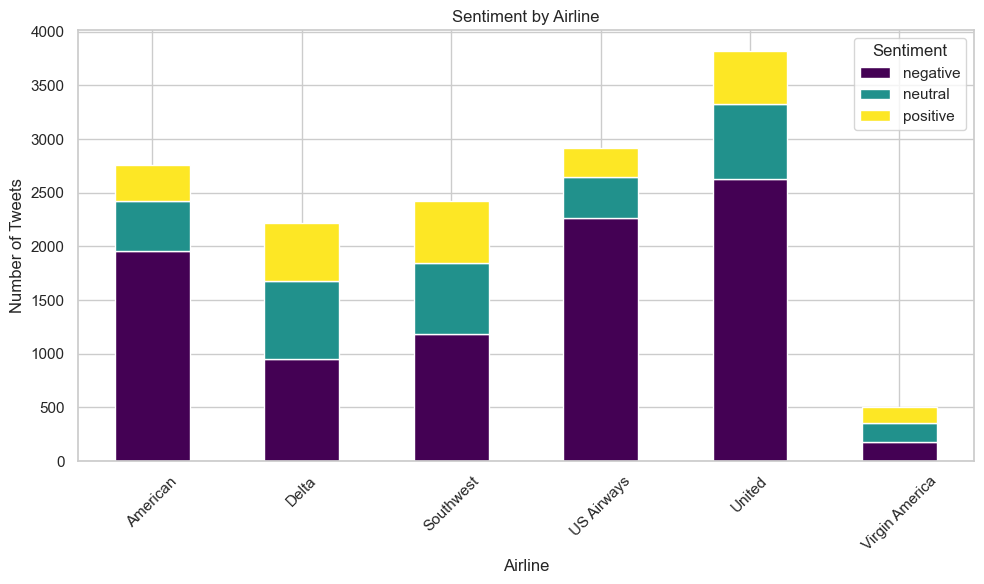

In [15]:
# Group by Airline and Sentiment
airline_sentiment = pd.crosstab(df['airline'], df['airline_sentiment'])

# Plot
airline_sentiment.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Sentiment by Airline')
plt.xlabel('Airline')
plt.ylabel('Number of Tweets')
plt.legend(title='Sentiment')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('images/sentiment_by_airline.png')
plt.show()

C:\Users\Abin\AppData\Local\Temp\ipykernel_2736\773790483.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reason_counts.values, y=reason_counts.index, palette='magma')


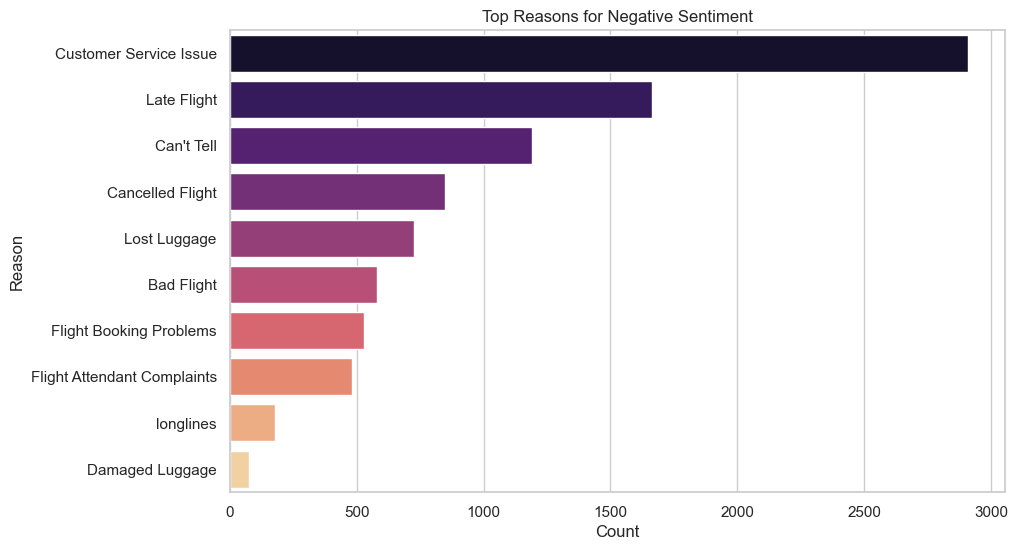

In [16]:
# Filter for negative tweets only
negative_tweets = df[df['airline_sentiment'] == 'negative']

# Count the reasons
reason_counts = negative_tweets['negativereason'].value_counts()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=reason_counts.values, y=reason_counts.index, palette='magma')
plt.title('Top Reasons for Negative Sentiment')
plt.xlabel('Count')
plt.ylabel('Reason')
plt.savefig('images/negative_reasons.png')
plt.show()